### What To Do in This Project (With This Dataset)
Step 1: Load and Understand Data

Read CSV

Check missing values

Understand AQI distribution

Step 2: Data Cleaning

Handle missing values

Remove rows where AQI is missing

Step 3: Feature Selection

Use pollutant columns to predict AQI

Step 4: Feature Scaling

StandardScaler (important for Ridge & Lasso)

Step 5: Train Regression Models

Linear Regression

Ridge Regression

Lasso Regression

Step 6: Model Evaluation

R² Score

RMSE

Step 7: Visualization

AQI distribution

Correlation heatmap

India AQI Map (State-wise) 

#### step 1:Load Libraries and Dataset

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression,Ridge,Lasso 
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import r2_score,mean_squared_error 



Step 2:load the dataset

In [2]:
df=pd.read_csv("city_day.csv")

df.head()
#df.info()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,01-01-2015,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,02-01-2015,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,03-01-2015,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,04-01-2015,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,05-01-2015,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


Step 3: Data Cleaning 

In [3]:
# Drop rows where AQI is missing
df=df.dropna(subset=['AQI'])


# Fill remaining missing values with mean
df.fillna(df.mean(numeric_only=True),inplace=True)


Step 4: Feature Selection

In [4]:
features=['PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3']
target='AQI'

X=df[features]
print(X)
y=df[target]

        PM2.5        PM10    NO2     CO    SO2      O3
28      83.13  118.454435  28.71   6.93  49.52   59.76
29      79.84  118.454435  28.68  13.85  48.49   97.07
30      94.52  118.454435  32.66  24.39  67.39  111.33
31     135.99  118.454435  42.08  43.48  75.23  102.70
32     178.33  118.454435  35.31  54.56  55.04  107.38
...       ...         ...    ...    ...    ...     ...
29526   15.02   50.940000  25.06   0.47   8.55   23.30
29527   24.38   74.090000  26.06   0.52  12.72   30.14
29528   22.91   65.730000  29.53   0.48   8.42   30.96
29529   16.64   49.970000  29.26   0.52   9.84   28.30
29530   15.00   66.000000  26.85   0.59   2.10   17.05

[24850 rows x 6 columns]


### Step 5: Exploratory Data Analysis (EDA)
AQI Distribution

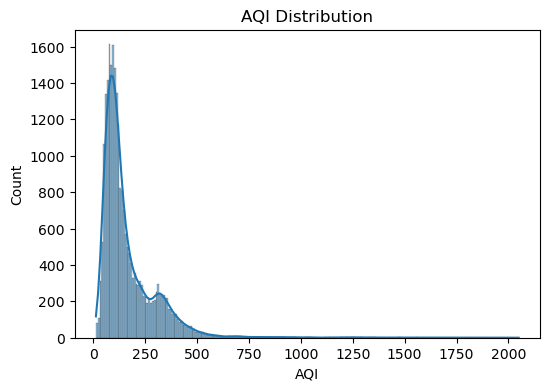

In [5]:
plt.figure(figsize=(6,4))
sns.histplot(y, kde=True)
plt.title("AQI Distribution")

plt.savefig("aqi_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


Correlation Heatmap


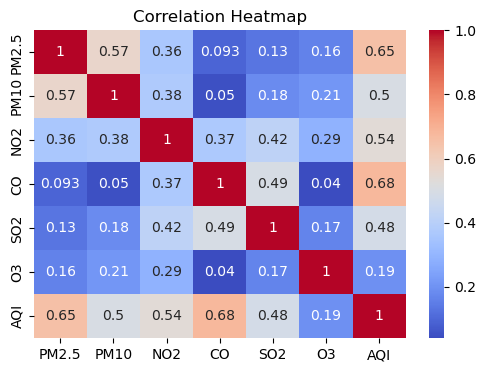

In [6]:
plt.figure(figsize=(6,4))
sns.heatmap(df[features + [target]].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")

plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

### Step 6:Train-Test Split & Scaling

In [7]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
scaler=StandardScaler() #It will standardize features (mean = 0, std = 1)
X_train_scaled=scaler.fit_transform(X_train) #train data only
#print(X_train_scaled)
X_test_scaled=scaler.transform(X_test) #test data only
print(X_test_scaled)

[[-0.40774986 -0.00330936 -0.5552785  -0.18784031 -0.54624176  0.05305495]
 [ 0.40549225  0.65148871  0.83810056 -0.16923038 -0.16153244 -0.25590263]
 [-0.16231339 -0.47276815 -0.77606039 -0.24510162 -0.45194459 -0.00213147]
 ...
 [-0.42108703  0.03303492  0.670061    0.42056114 -0.47161394  0.77036165]
 [-0.36237095 -0.00330936 -0.55773163 -0.24080702 -0.6052498  -0.55501484]
 [-0.26526984 -0.00330936 -0.15950651 -0.21790249 -0.48029159 -0.82834151]]


### Step 7:Regression Models

In [8]:
#Linear Regression
# Linear Regression finds the best-fitting line by minimizing Mean Squared Error (MSE). 
lr=LinearRegression()
lr.fit(X_train_scaled,y_train)
y_pred_lr=lr.predict(X_test_scaled)
print("The Linear Regression:",y_pred_lr)

#Ridge Regression 
#Ridge Regression = Linear Regression + L2 Regularization,Shrinks coefficients toward zero,Never makes coefficients exactly zero,Good for multicollinearity
ridge=Ridge(alpha=100)
ridge.fit(X_train_scaled,y_train)
y_pred_ridge=ridge.predict(X_test_scaled)
print("The Ridge Regression:",y_pred_ridge)

#Lasso Regression
#Lasso Regression = Linear Regression + L1 Regularization Can make some coefficients exactly zero,Performs feature selection
lasso=Lasso(alpha=1)
lasso.fit(X_train_scaled,y_train)
y_pred_lasso=lasso.predict(X_test_scaled)
print("The Lasso Regression",y_pred_lasso)
print()
print("LR coefficients:", lr.coef_)
print("Ridge coefficients:", ridge.coef_)
print("Lasso coefficients:", lasso.coef_)


The Linear Regression: [113.81438135 197.05755468 115.22480158 ... 174.93439821 109.25902397
 120.53985528]
The Ridge Regression: [113.85724382 197.20206521 115.1377558  ... 174.95413973 109.32222004
 120.68078876]
The Lasso Regression [114.32703971 196.9106935  115.87636135 ... 174.43928584 110.24639311
 121.60505315]

LR coefficients: [68.39692457 21.7709277   6.16896867 81.7061645  11.89582003  4.29941734]
Ridge coefficients: [67.9764858  21.80980459  6.42492253 81.16151282 12.0547783   4.26558579]
Lasso coefficients: [67.90187114 21.3214757   6.1485844  81.00137943 11.522718    3.57946776]


## Step 8: INDIA MAP VISUALIZATION (AQI STATE-WISE)

##### Prepare AQI by State

Since dataset has cities, we calculate average AQI per city, then map them.

In [9]:
city_aqi=df.groupby("City")["AQI"].mean().reset_index()
print(city_aqi)

                  City         AQI
0            Ahmedabad  452.122939
1               Aizawl   34.765766
2            Amaravati   95.299643
3             Amritsar  119.920959
4            Bengaluru   94.318325
5               Bhopal  132.827338
6         Brajrajnagar  150.280505
7           Chandigarh   96.498328
8              Chennai  114.502654
9           Coimbatore   73.023256
10               Delhi  259.487744
11           Ernakulam   92.359477
12            Gurugram  225.123882
13            Guwahati  140.111111
14           Hyderabad  109.207447
15              Jaipur  133.679159
16          Jorapokhar  159.251621
17               Kochi  104.284810
18             Kolkata  140.566313
19             Lucknow  217.973059
20              Mumbai  105.352258
21               Patna  240.782042
22            Shillong   53.795122
23             Talcher  172.886819
24  Thiruvananthapuram   75.878327
25       Visakhapatnam  117.269855


In [10]:
! pip install geopandas


In [11]:
import pandas as pd
df = pd.read_csv("city_day.csv")

print(df.head())
city_state_map = {
    "Ahmedabad": "Gujarat",
    "Aizawl": "Mizoram",
    "Amaravati": "Andhra Pradesh",
    "Amritsar": "Punjab",
    "Bengaluru": "Karnataka",
    "Bhopal": "Madhya Pradesh",
    "Brajrajnagar": "Odisha",
    "Chandigarh": "Chandigarh",
    "Chennai": "Tamil Nadu",
    "Coimbatore": "Tamil Nadu",
    "Delhi": "Delhi",
    "Ernakulam": "Kerala",
    "Gurugram": "Haryana",
    "Guwahati": "Assam",
    "Hyderabad": "Telangana",
    "Jaipur": "Rajasthan",
    "Jorapokhar": "Jharkhand",
    "Kochi": "Kerala",
    "Kolkata": "West Bengal",
    "Lucknow": "Uttar Pradesh",
    "Mumbai": "Maharashtra",
    "Patna": "Bihar",
    "Shillong": "Meghalaya",
    "Talcher": "Odisha",
    "Thiruvananthapuram": "Kerala",
    "Visakhapatnam": "Andhra Pradesh"
}

# Add State column
df["State"] = df["City"].map(city_state_map)


        City        Date  PM2.5  PM10     NO    NO2    NOx  NH3     CO    SO2  \
0  Ahmedabad  01-01-2015    NaN   NaN   0.92  18.22  17.15  NaN   0.92  27.64   
1  Ahmedabad  02-01-2015    NaN   NaN   0.97  15.69  16.46  NaN   0.97  24.55   
2  Ahmedabad  03-01-2015    NaN   NaN  17.40  19.30  29.70  NaN  17.40  29.07   
3  Ahmedabad  04-01-2015    NaN   NaN   1.70  18.48  17.97  NaN   1.70  18.59   
4  Ahmedabad  05-01-2015    NaN   NaN  22.10  21.42  37.76  NaN  22.10  39.33   

       O3  Benzene  Toluene  Xylene  AQI AQI_Bucket  
0  133.36     0.00     0.02    0.00  NaN        NaN  
1   34.06     3.68     5.50    3.77  NaN        NaN  
2   30.70     6.80    16.40    2.25  NaN        NaN  
3   36.08     4.43    10.14    1.00  NaN        NaN  
4   39.31     7.01    18.89    2.78  NaN        NaN  


Adding the Missing States

In [12]:
# Adding the missing states
all_states_ut = [
    # States
    "Andhra Pradesh","Arunachal Pradesh","Assam","Bihar","Chhattisgarh",
    "Goa","Gujarat","Haryana","Himachal Pradesh","Jharkhand","Karnataka",
    "Kerala","Madhya Pradesh","Maharashtra","Manipur","Meghalaya","Mizoram",
    "Nagaland","Odisha","Punjab","Rajasthan","Sikkim","Tamil Nadu",
    "Telangana","Tripura","Uttar Pradesh","Uttarakhand","West Bengal",

    # Union Territories
    "Andaman and Nicobar Islands","Chandigarh",
    "Dadra and Nagar Haveli and Daman and Diu",
    "Delhi","Jammu and Kashmir","Ladakh",
    "Lakshadweep","Puducherry"
]

existing_states = df["State"].dropna().unique()
missing_states = list(set(all_states_ut) - set(existing_states))

print("Missing States & UTs:", missing_states)



Missing States & UTs: ['Nagaland', 'Chhattisgarh', 'Himachal Pradesh', 'Goa', 'Dadra and Nagar Haveli and Daman and Diu', 'Ladakh', 'Tripura', 'Manipur', 'Puducherry', 'Lakshadweep', 'Jammu and Kashmir', 'Arunachal Pradesh', 'Uttarakhand', 'Andaman and Nicobar Islands', 'Sikkim']


In [13]:
missing_rows = []

for state in missing_states:
    missing_rows.append({
        "City": "Not Available",
        "Date": None,
        "AQI": None,
        "State": state
    })

missing_df = pd.DataFrame(missing_rows)

# Append to original data
df_modified = pd.concat([df, missing_df], ignore_index=True)


C:\Users\91939\AppData\Local\Temp\ipykernel_20536\4155560557.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_modified = pd.concat([df, missing_df], ignore_index=True)


In [14]:
df_modified.to_csv("city_day_modified.csv", index=False)

print(" Modified CSV saved as city_day_modified.csv")


 Modified CSV saved as city_day_modified.csv


In [15]:
# Add State column
df["State"] = df["City"].map(city_state_map)

# Remove rows without state or AQI
df = df.dropna(subset=["State", "AQI"])

Calculate the Average AQI per State

In [16]:

state_aqi = df.groupby("State")["AQI"].mean().reset_index()

Load India Map (GeoJSON)

In [17]:
import geopandas as gpd
india_map = gpd.read_file(
    "https://raw.githubusercontent.com/udit-001/india-maps-data/main/geojson/india.geojson"
)

india_map["State"] = india_map["st_nm"]

# ===============================
#  Merge AQI Data with Map
# ===============================
india_aqi_map = india_map.merge(state_aqi, on="State", how="left")

In [18]:
print(india_aqi_map.columns)


Index(['id', 'district', 'dt_code', 'st_nm', 'st_code', 'year', 'geometry',
       'State', 'AQI'],
      dtype='object')


In [21]:
def categorize_aqi(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Satisfactory"
    elif aqi <= 200:
        return "Moderate"
    elif aqi <= 300:
        return "Poor"
    elif aqi <= 400:
        return "Very Poor"
    else:
        return "Severe"

# Create the AQI_Category column
india_aqi_map["AQI_Category"] = india_aqi_map["AQI"].apply(categorize_aqi)

# Define color mapping
aqi_color = {
    "Good": "green",
    "Satisfactory": "lightgreen",
    "Moderate": "yellow",
    "Poor": "orange",
    "Very Poor": "red",
    "Severe": "maroon"
}

# Map colors
india_aqi_map["Color"] = india_aqi_map["AQI_Category"].map(aqi_color)

In [22]:
def aqi_color(category):
    if category == "Good":
        return "#90EE90"     # Light Green
    elif category == "Satisfactory":
        return "#008000"     # Green
    elif category == "Moderate":
        return "#FFA500"     # Orange
    elif category == "Poor":
        return "#FF0000"     # Red
    else:
        return "#D3D3D3"     # Grey (No Data)

india_aqi_map["Color"] = india_aqi_map["AQI_Category"].apply(aqi_color)


Plot India AQI Map

<Figure size 1400x1200 with 0 Axes>

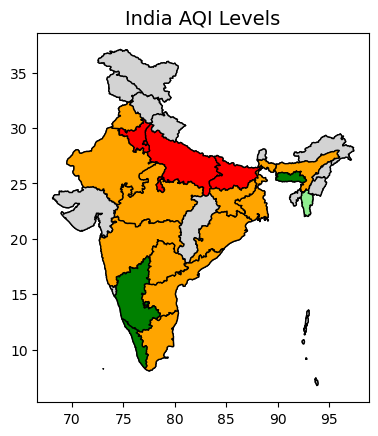

In [23]:

plt.figure(figsize=(14,12))
india_aqi_map.plot(
    color=india_aqi_map["Color"],
    edgecolor="black",
    legend=False
)
plt.title("India AQI Levels", fontsize=14)
plt.savefig("Map_AQI.png", dpi=300, bbox_inches="tight")
plt.show()